# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

*The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).*

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [2]:
import pandas as pd
import time
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, precision_score
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import GridSearchCV

In [3]:
df = pd.read_csv('/content/bank-additional-full.csv', sep = ';')

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
# Drop 'duration': it leaks the outcome (duration=0 implies y='no', and duration
# is only known after the call ends), so it cannot be used for a realistic
# pre-call predictive model.
df = df.drop('duration', axis = 1)



In [7]:
# Encode binary yes/no fields as 1/0 for modeling
df['housing'] = df['housing'].map({'yes': 1, 'no': 0, 'unknown': 0})
df['loan'] = df['loan'].map({'yes': 1, 'no': 0, 'unknown': 0})
df['y'] = df['y'].map({'yes': 1, 'no': 0, 'unknown': 0})

df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,0,0,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,0,0,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,1,0,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,0,0,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,0,1,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


In [8]:
# pdays=999 is "never contacted before," not a real amount of days
# make it its own binary
df['not_previously_contacted'] = (df['pdays'] == 999).astype(int)

# Replace with 0 so pdays stays numeric and meaningful;
# the flag above distinguishes a "fake" 0 from a real same-day contact
df['pdays'] = df['pdays'].replace(999, 0)
df['pdays'].value_counts()


,count
pdays,
0,39688
3,439
6,412
4,118
9,64
2,61
7,60
12,58
10,52


### Problem 4: Understanding the Task

**Business Objective:** Predict if a client will subscribe to a term deposit (y),
so the bank can prioritize who to call.

Recall is the most important metric here. Missing a real "yes" costs a lost
subscriber, while calling a "no" only costs a few minutes of agent time. Since
a missed subscriber is much more expensive than a wasted call, it's worth
accepting more false positives to catch more true subscribers.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [9]:
# Separate features from target
X = df.drop('y', axis = 1)
y = df['y']


In [10]:
# Split into train/test sets and keep the ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [11]:
# Baseline: always predicting the majority class ('no') gives 88% accuracy
y.value_counts(normalize = True)


,proportion
y,
0,0.887346
1,0.112654


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [12]:
#columns to be encode using one hot encoder
cat_cols = ['job', 'marital', 'education','default', 'contact', 'month', 'day_of_week', 'poutcome', 'not_previously_contacted']

#create the transformer and use standard scaler to scale the data
log_pipe_transformer = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), cat_cols),
    remainder=StandardScaler()
)

In [13]:
#create the log pipeline
log_pipe = Pipeline([
    ('transformer', log_pipe_transformer),
    ('logreg', LogisticRegression())
])

# time.time() before/after fit captures training duration for the comparison table
start = time.time()
log_pipe.fit(X_train, y_train)
log_time = time.time() - start

### Problem 9: Score the Logistic Regression Model

What is the accuracy of your model?

Baseline (majority class) accuracy: 0.8873
Model accuracy: 0.9007
Precision: 0.6858
Recall: 0.2188


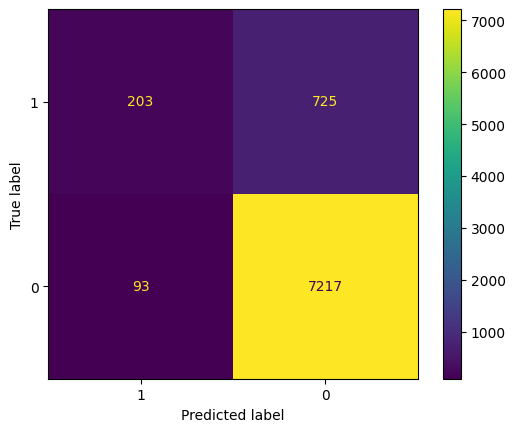

Train Accuracy: 0.9001
Train Recall: 0.2276


In [14]:
# Score for Logistic Regression compared to the baseline
from sklearn.metrics import precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Baseline vs. logistic model accuracy
baseline = y_train.value_counts(normalize=True).iloc[0]
print(f'Baseline (majority class) accuracy: {baseline:.4f}')
print(f'Model accuracy: {log_pipe.score(X_test, y_test):.4f}')

# Logistic regression predictions
log_preds = log_pipe.predict(X_test)

# Precision: of everyone predicted 'yes', how many actually said yes?
log_precision = precision_score(y_test, log_preds, pos_label = 1)
print(f'Precision: {log_precision:.4f}')

# Recall: of everyone who actually said yes, how many did the model catch?
log_recall = recall_score(y_test, log_preds, pos_label=1)
print(f'Recall: {log_recall:.4f}')

# Confusion matrix for a visual breakdown
cm = confusion_matrix(y_test, log_preds, labels=[1,0])  # positive class first
disp = ConfusionMatrixDisplay(cm, display_labels=[1,0])
disp.plot()
plt.show()

# Train accuracy and recall, added to check for overfitting against the test scores above
log_train_preds = log_pipe.predict(X_train)
log_train_accuracy = log_pipe.score(X_train, y_train)
print(f'Train Accuracy: {log_train_accuracy:.4f}')

log_train_recall = recall_score(y_train, log_train_preds, pos_label=1)
print(f'Train Recall: {log_train_recall:.4f}')

In [15]:
# Apply class_weight='balanced' to improve recall
#— this weights a missed "yes" more heavily during training
log_weight_pipe_transformer = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), cat_cols),
    remainder=StandardScaler()
)

log_weight_pipe = Pipeline([
    ('transformer', log_weight_pipe_transformer),
    ('logreg', LogisticRegression(class_weight='balanced'))
])


start = time.time()
log_weight_pipe.fit(X_train, y_train)
log_weight_time = time.time() - start


# Logistic Regression with Hyperparameters

Baseline (majority class) accuracy: 0.8873
Model accuracy: 0.8349
Precision: 0.3678
Recall: 0.6476


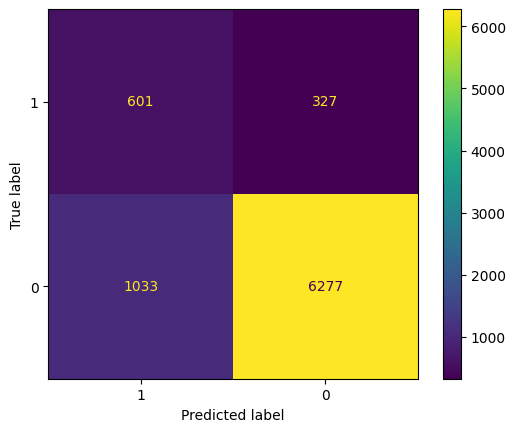

Train Accuracy: 0.8288
Train Recall: 0.6263


In [53]:
# Baseline vs. class-weighted logistic model accuracy
baseline = y_train.value_counts(normalize=True).iloc[0]
print(f'Baseline (majority class) accuracy: {baseline:.4f}')
print(f'Model accuracy: {log_weight_pipe.score(X_test, y_test):.4f}')

# Class-weighted logistic regression predictions
log_weight_preds = log_weight_pipe.predict(X_test)

# Precision: of everyone predicted 'yes', how many actually said yes?
log_weight_precision = precision_score(y_test, log_weight_preds, pos_label = 1)
print(f'Precision: {log_weight_precision:.4f}')

# Recall: of everyone who actually said yes, how many did the model catch?
log_weight_recall = recall_score(y_test, log_weight_preds, pos_label=1)
print(f'Recall: {log_weight_recall:.4f}')

# Confusion matrix for a visual breakdown
cm = confusion_matrix(y_test, log_weight_preds, labels=[1,0])  # positive class first
disp = ConfusionMatrixDisplay(cm, display_labels=[1,0])
disp.plot()
plt.show()

# Train accuracy and recall, added to check for overfitting against the test scores above
log_weight_train_preds = log_weight_pipe.predict(X_train)
log_weight_train_accuracy = log_weight_pipe.score(X_train, y_train)
print(f'Train Accuracy: {log_weight_train_accuracy:.4f}')

log_weight_train_recall = recall_score(y_train, log_weight_train_preds, pos_label=1)
print(f'Train Recall: {log_weight_train_recall:.4f}')

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Then we will adjust the hyperparameters of each model.

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

#### Base KNN Model


In [17]:
#create the transformer for knn
knn_base_pipe_transformer = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), cat_cols),
    remainder=StandardScaler()
)

knn_base_pipe = Pipeline([
    ('transformer', knn_base_pipe_transformer ),
    ('knn', KNeighborsClassifier())
])

start = time.time()
knn_base_pipe.fit(X_train, y_train)
knn_base_time = time.time() - start


Baseline (majority class) accuracy: 0.8873
KNN Model accuracy: 0.8960
Precision: 0.5787
Recall: 0.2812


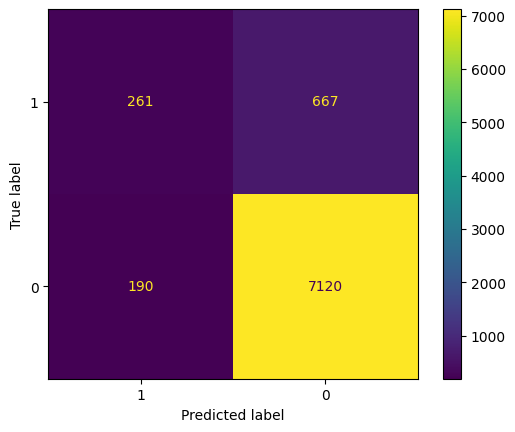

Train Accuracy: 0.9124
Train Recall: 0.3753


In [18]:
baseline = y_train.value_counts(normalize=True).iloc[0]
print(f'Baseline (majority class) accuracy: {baseline:.4f}')
print(f'KNN Model accuracy: {knn_base_pipe.score(X_test, y_test):.4f}')

# KNN predictions
knn_base_preds = knn_base_pipe.predict(X_test)

# Precision: of everyone predicted 'yes', how many actually said yes?
knn_base_pipe_precision = precision_score(y_test, knn_base_preds, pos_label = 1)
print(f'Precision: {knn_base_pipe_precision:.4f}')

# Recall: of everyone who actually said yes, how many did the model catch?
knn_base_pipe_recall = recall_score(y_test, knn_base_preds, pos_label=1)
print(f'Recall: {knn_base_pipe_recall:.4f}')

# Confusion matrix for a visual breakdown
cm = confusion_matrix(y_test, knn_base_preds, labels=[1,0])  # positive class first
disp = ConfusionMatrixDisplay(cm, display_labels=[1,0])
disp.plot()
plt.show()

# Train accuracy and recall, added to check for overfitting against the test scores above
knn_base_train_preds = knn_base_pipe.predict(X_train)
knn_base_pipe_train_accuracy = knn_base_pipe.score(X_train, y_train)
print(f'Train Accuracy: {knn_base_pipe_train_accuracy:.4f}')

knn_base_pipe_train_recall = recall_score(y_train, knn_base_train_preds, pos_label=1)
print(f'Train Recall: {knn_base_pipe_train_recall:.4f}')

#### KNN Model with Hyperparameters


In [19]:
from sklearn.model_selection import GridSearchCV

knn_pipe_transformer = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), cat_cols),
    remainder=StandardScaler()
)

knn_pipe = Pipeline([
    ('transformer', knn_pipe_transformer),
    ('knn', KNeighborsClassifier(n_neighbors = 5, weights = 'distance'))
])


start = time.time()
knn_pipe.fit(X_train, y_train)
knn_time = time.time() - start


In [20]:
baseline = y_train.value_counts(normalize=True).iloc[0]
print(f'Baseline (majority class) accuracy: {baseline:.4f}')
print(f'KNN Model accuracy: {knn_pipe.score(X_test, y_test):.4f}')

# KNN predictions
knn_pipe_preds = knn_pipe.predict(X_test)

# Precision: of everyone predicted 'yes', how many actually said yes?
knn_pipe_precision = precision_score(y_test, knn_pipe_preds, pos_label = 1)
print(f'Precision: {knn_pipe_precision:.4f}')

# Recall: of everyone who actually said yes, how many did the model catch?
knn_pipe_recall = recall_score(y_test, knn_pipe_preds, pos_label=1)
print(f'Recall: {knn_pipe_recall:.4f}')

# Train accuracy and recall, added to check for overfitting against the test scores above
knn_pipe_train_preds = knn_pipe.predict(X_train)
knn_pipe_train_accuracy = knn_pipe.score(X_train, y_train)
print(f'Train Accuracy: {knn_pipe_train_accuracy:.4f}')

knn_pipe_train_recall = recall_score(y_train, knn_pipe_train_preds, pos_label=1)
print(f'Train Recall: {knn_pipe_train_recall:.4f}')

Baseline (majority class) accuracy: 0.8873
KNN Model accuracy: 0.8876
Precision: 0.5019
Recall: 0.2899
Train Accuracy: 0.9952
Train Recall: 0.9580


#### Decision Tree (Base)


In [21]:
# Decision tree with default hyperparameters
tree_pipe_transformer = make_column_transformer(
    (OneHotEncoder(drop='if_binary', handle_unknown='ignore'), cat_cols),
    remainder=StandardScaler()
)

tree_pipe = Pipeline([
    ('transformer', tree_pipe_transformer),
    ('tree', DecisionTreeClassifier(random_state = 42))
])

start = time.time()
tree_pipe.fit(X_train, y_train)
tree_time = time.time() - start


In [22]:
baseline = y_train.value_counts(normalize=True).iloc[0]
print(f'Baseline (majority class) accuracy: {baseline:.4f}')
print(f'Decistion Tree Model accuracy: {tree_pipe.score(X_test, y_test):.4f}')

# Decision tree predictions
tree_pipe_preds = tree_pipe.predict(X_test)

# Precision: of everyone predicted 'yes', how many actually said yes?
tree_pipe_precision = precision_score(y_test, tree_pipe_preds, pos_label = 1)
print(f'Precision: {tree_pipe_precision:.4f}')

# Recall: of everyone who actually said yes, how many did the model catch?
tree_pipe_recall = recall_score(y_test, tree_pipe_preds, pos_label=1)
print(f'Recall: {tree_pipe_recall:.4f}')

# Train accuracy and recall, added to check for overfitting against the test scores above
tree_pipe_train_preds = tree_pipe.predict(X_train)
tree_pipe_train_accuracy = tree_pipe.score(X_train, y_train)
print(f'Train Accuracy: {tree_pipe_train_accuracy:.4f}')

tree_pipe_train_recall = recall_score(y_train, tree_pipe_train_preds, pos_label=1)
print(f'Train Recall: {tree_pipe_train_recall:.4f}')

Baseline (majority class) accuracy: 0.8873
Decistion Tree Model accuracy: 0.8418
Precision: 0.3131
Recall: 0.3384
Train Accuracy: 0.9952
Train Recall: 0.9574


#### Decision Tree with Hyperparameters


In [23]:
tree_pipe_two_transformer = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), cat_cols),
    remainder=StandardScaler()
)

tree_pipe_two = Pipeline([
    ('transformer', tree_pipe_two_transformer),
    ('tree', DecisionTreeClassifier(max_depth=4, class_weight='balanced'))
])

start = time.time()
tree_pipe_two.fit(X_train, y_train)
tree_two_time = time.time() - start

In [24]:
baseline = y_train.value_counts(normalize=True).iloc[0]
print(f'Baseline (majority class) accuracy: {baseline:.4f}')
print(f'Decistion Tree with Hyperparameters Model accuracy: {tree_pipe_two.score(X_test, y_test):.4f}')

# Decision tree (tuned) predictions
tree_pipe_two_preds = tree_pipe_two.predict(X_test)

# Precision: of everyone predicted 'yes', how many actually said yes?
tree_pipe_two_precision = precision_score(y_test, tree_pipe_two_preds, pos_label = 1)
print(f'Precision: {tree_pipe_two_precision:.4f}')

# Recall: of everyone who actually said yes, how many did the model catch?
tree_pipe_two_recall = recall_score(y_test, tree_pipe_two_preds, pos_label=1)
print(f'Recall: {tree_pipe_two_recall:.4f}')

# Train accuracy and recall, added to check for overfitting against the test scores above
tree_pipe_two_train_preds = tree_pipe_two.predict(X_train)
tree_pipe_two_train_accuracy = tree_pipe_two.score(X_train, y_train)
print(f'Train Accuracy: {tree_pipe_two_train_accuracy:.4f}')

tree_pipe_two_train_recall = recall_score(y_train, tree_pipe_two_train_preds, pos_label=1)
print(f'Train Recall: {tree_pipe_two_train_recall:.4f}')

Baseline (majority class) accuracy: 0.8873
Decistion Tree with Hyperparameters Model accuracy: 0.8468
Precision: 0.3872
Recall: 0.6175
Train Accuracy: 0.8423
Train Recall: 0.6008


### SVMs
* Using the smaller sample here — the full dataset crashed the kernel during SVM training.
* SVM results below aren't directly comparable to the full-dataset models above.
* Dataset contains 4,111 rows


In [25]:
# Load a smaller sample to train SVMs, which crashed the kernel on the full dataset
partial_bank = pd.read_csv('/content/bank-additional.csv', sep = ';')


In [26]:
# Drop 'duration' for the same leakage reason as the full dataset above
partial_bank = partial_bank.drop('duration', axis = 1)


In [27]:
# Encode binary yes/no fields as 1/0, consistent with the full dataset
partial_bank['housing'] = partial_bank['housing'].map({'yes': 1, 'no': 0, 'unknown': 0})
partial_bank['loan'] = partial_bank['loan'].map({'yes': 1, 'no': 0, 'unknown': 0})
partial_bank['y'] = partial_bank['y'].map({'yes': 1, 'no': 0, 'unknown': 0})


In [28]:
# pdays=999 is a sentinel for "never contacted before," not a real day count —
# capture that as its own binary flag before treating pdays as numeric
partial_bank['not_previously_contacted'] = (partial_bank['pdays'] == 999).astype(int)

# Replace the sentinel with 0 so pdays stays numeric and meaningful;
# the flag above distinguishes a "fake" 0 from a real same-day contact
partial_bank['pdays'] = partial_bank['pdays'].replace(999, 0)
partial_bank['pdays'].value_counts()


,count
pdays,
0,3961
3,52
6,42
4,14
7,10
10,8
12,5
5,4
2,4


In [29]:
#set up training sets
X_partial = partial_bank.drop('y', axis = 1)
y_partial = partial_bank['y']

In [30]:
X_train_partial, X_test_partial, y_train_partial, y_test_partial = train_test_split(X_partial, y_partial, test_size = 0.2, random_state = 42, stratify = y_partial)

#### SVC Linear Model


In [31]:
# SVC with a linear kernel, default hyperparameters
svc_linear_pipe_transformer = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), cat_cols),
    remainder=StandardScaler()
)

svc_linear_pipe = Pipeline([
    ('transformer', svc_linear_pipe_transformer),
    ('svc', SVC(kernel = 'linear'))
])

start = time.time()
svc_linear_pipe.fit(X_train_partial, y_train_partial)
svc_linear_time = time.time() - start


In [32]:
baseline = y_train_partial.value_counts(normalize=True).iloc[0]
print(f'Baseline (majority class) accuracy: {baseline:.4f}')
print(f'SVC Linear Model accuracy: {svc_linear_pipe.score(X_test_partial, y_test_partial):.4f}')

# SVC linear predictions
preds = svc_linear_pipe.predict(X_test_partial)

# Precision: of everyone predicted 'yes', how many actually said yes?
svc_linear_pipe_precision = precision_score(y_test_partial, preds, pos_label = 1)
print(f'Precision: {svc_linear_pipe_precision:.4f}')

# Recall: of everyone who actually said yes, how many did the model catch?
svc_linear_pipe_recall = recall_score(y_test_partial, preds, pos_label=1)
print(f'Recall: {svc_linear_pipe_recall:.4f}')

# Train accuracy and recall, added to check for overfitting against the test scores above
svc_linear_pipe_train_preds = svc_linear_pipe.predict(X_train_partial)
svc_linear_pipe_train_accuracy = svc_linear_pipe.score(X_train_partial, y_train_partial)
print(f'Train Accuracy: {svc_linear_pipe_train_accuracy:.4f}')

svc_linear_pipe_train_recall = recall_score(y_train_partial, svc_linear_pipe_train_preds, pos_label=1)
print(f'Train Recall: {svc_linear_pipe_train_recall:.4f}')

Baseline (majority class) accuracy: 0.8904
SVC Linear Model accuracy: 0.9053
Precision: 0.7727
Recall: 0.1889
Train Accuracy: 0.9002
Train Recall: 0.2078


#### SVC Linear with Hyperparameters


In [33]:
# SVC linear with class_weight='balanced' to penalize minority-class mistakes more, improving recall
svc_linear_two_pipe_transformer = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), cat_cols),
    remainder=StandardScaler()
)

svc_linear_two_pipe = Pipeline([
    ('transformer', svc_linear_two_pipe_transformer),
    ('svc', SVC(kernel='linear', class_weight='balanced', probability=True))
])

start = time.time()
svc_linear_two_pipe.fit(X_train_partial, y_train_partial)
svc_linear_two_time = time.time() - start

baseline = y_train_partial.value_counts(normalize=True).iloc[0]
print(f'Baseline (majority class) accuracy: {baseline:.4f}')
print(f'SVC Linear Model accuracy: {svc_linear_two_pipe.score(X_test_partial, y_test_partial):.4f}')

# SVC linear (balanced) predictions
preds = svc_linear_two_pipe.predict(X_test_partial)

# Precision: of everyone predicted 'yes', how many actually said yes?
svc_linear_two_pipe_precision = precision_score(y_test_partial, preds, pos_label = 1)
print(f'Precision: {svc_linear_two_pipe_precision:.4f}')

# Recall: of everyone who actually said yes, how many did the model catch?
svc_linear_two_pipe_recall = recall_score(y_test_partial, preds, pos_label=1)
print(f'Recall: {svc_linear_two_pipe_recall:.4f}')

# Train accuracy and recall, added to check for overfitting against the test scores above
svc_linear_two_pipe_train_preds = svc_linear_two_pipe.predict(X_train_partial)
svc_linear_two_pipe_train_accuracy = svc_linear_two_pipe.score(X_train_partial, y_train_partial)
print(f'Train Accuracy: {svc_linear_two_pipe_train_accuracy:.4f}')

svc_linear_two_pipe_train_recall = recall_score(y_train_partial, svc_linear_two_pipe_train_preds, pos_label=1)
print(f'Train Recall: {svc_linear_two_pipe_train_recall:.4f}')

Baseline (majority class) accuracy: 0.8904
SVC Linear Model accuracy: 0.8398
Precision: 0.3581
Recall: 0.5889
Train Accuracy: 0.8364
Train Recall: 0.6011


#### SVC Poly


In [34]:
# SVC with a poly, default hyperparameters
svc_poly_pipe_transformer = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), cat_cols),
    remainder=StandardScaler()
)

svc_poly_pipe = Pipeline([
    ('transformer', svc_poly_pipe_transformer),
    ('svc', SVC(kernel = 'poly'))
])

start = time.time()
svc_poly_pipe.fit(X_train_partial, y_train_partial)
svc_poly_time = time.time() - start


In [35]:
baseline = y_train_partial.value_counts(normalize=True).iloc[0]
print(f'Baseline (majority class) accuracy: {baseline:.4f}')
print(f'SVC Poly Model accuracy: {svc_poly_pipe.score(X_test_partial, y_test_partial):.4f}')

# SVC poly predictions
preds = svc_poly_pipe.predict(X_test_partial)

# Precision: of everyone predicted 'yes', how many actually said yes?
svc_poly_pipe_precision = precision_score(y_test_partial, preds, pos_label = 1)
print(f'Precision: {svc_poly_pipe_precision:.4f}')

# Recall: of everyone who actually said yes, how many did the model catch?
svc_poly_pipe_recall = recall_score(y_test_partial, preds, pos_label=1)
print(f'Recall: {svc_poly_pipe_recall:.4f}')

# Train accuracy and recall, added to check for overfitting against the test scores above
svc_poly_pipe_train_preds = svc_poly_pipe.predict(X_train_partial)
svc_poly_pipe_train_accuracy = svc_poly_pipe.score(X_train_partial, y_train_partial)
print(f'Train Accuracy: {svc_poly_pipe_train_accuracy:.4f}')

svc_poly_pipe_train_recall = recall_score(y_train_partial, svc_poly_pipe_train_preds, pos_label=1)
print(f'Train Recall: {svc_poly_pipe_train_recall:.4f}')

Baseline (majority class) accuracy: 0.8904
SVC Poly Model accuracy: 0.8920
Precision: 0.5294
Recall: 0.1000
Train Accuracy: 0.9308
Train Recall: 0.3767


#### SVC Poly with Hyperparameters


In [36]:
# SVC polynomial kernel with degree=2
svc_poly_two_pipe_transformer = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), cat_cols),
    remainder=StandardScaler()
)

svc_poly_two_pipe = Pipeline([
    ('transformer', svc_poly_two_pipe_transformer),
    ('svc', SVC(kernel = 'poly', coef0 = 0.0,  degree = 2, gamma='scale'))
])

start = time.time()
svc_poly_two_pipe.fit(X_train_partial, y_train_partial)
svc_poly_two_time = time.time() - start

baseline = y_train_partial.value_counts(normalize=True).iloc[0]
print(f'Baseline (majority class) accuracy: {baseline:.4f}')
print(f'SVC Poly Model accuracy: {svc_poly_two_pipe.score(X_test_partial, y_test_partial):.4f}')

# SVC poly (tuned) predictions
preds = svc_poly_two_pipe.predict(X_test_partial)

# Precision: of everyone predicted 'yes', how many actually said yes?
svc_poly_two_pipe_precision = precision_score(y_test_partial, preds, pos_label = 1)
print(f'Precision: {svc_poly_two_pipe_precision:.4f}')

# Recall: of everyone who actually said yes, how many did the model catch?
svc_poly_two_pipe_recall = recall_score(y_test_partial, preds, pos_label=1)
print(f'Recall: {svc_poly_two_pipe_recall:.4f}')

# Train accuracy and recall, added to check for overfitting against the test scores above
svc_poly_two_pipe_train_preds = svc_poly_two_pipe.predict(X_train_partial)
svc_poly_two_pipe_train_accuracy = svc_poly_two_pipe.score(X_train_partial, y_train_partial)
print(f'Train Accuracy: {svc_poly_two_pipe_train_accuracy:.4f}')

svc_poly_two_pipe_train_recall = recall_score(y_train_partial, svc_poly_two_pipe_train_preds, pos_label=1)
print(f'Train Recall: {svc_poly_two_pipe_train_recall:.4f}')

Baseline (majority class) accuracy: 0.8904
SVC Poly Model accuracy: 0.8944
Precision: 0.6364
Recall: 0.0778
Train Accuracy: 0.9083
Train Recall: 0.2161


#### SVC RBF


In [37]:
# SVC with an RBF kernel, default hyperparameters
svc_rbf_pipe_transformer = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), cat_cols),
    remainder=StandardScaler()
)

svc_rbf_pipe = Pipeline([
    ('transformer', svc_rbf_pipe_transformer),
    ('svc', SVC(kernel = 'rbf'))
])

start = time.time()
svc_rbf_pipe.fit(X_train_partial, y_train_partial)
svc_rbf_time = time.time() - start

baseline = y_train_partial.value_counts(normalize=True).iloc[0]
print(f'Baseline (majority class) accuracy: {baseline:.4f}')
print(f'SVC RBF Model accuracy: {svc_rbf_pipe.score(X_test_partial, y_test_partial):.4f}')

# SVC RBF predictions
preds = svc_rbf_pipe.predict(X_test_partial)

# Precision: of everyone predicted 'yes', how many actually said yes?
svc_rbf_pipe_precision = precision_score(y_test_partial, preds, pos_label = 1)
print(f'Precision: {svc_rbf_pipe_precision:.4f}')

# Recall: of everyone who actually said yes, how many did the model catch?
svc_rbf_pipe_recall = recall_score(y_test_partial, preds, pos_label=1)
print(f'Recall: {svc_rbf_pipe_recall:.4f}')

# Train accuracy and recall, added to check for overfitting against the test scores above
svc_rbf_pipe_train_preds = svc_rbf_pipe.predict(X_train_partial)
svc_rbf_pipe_train_accuracy = svc_rbf_pipe.score(X_train_partial, y_train_partial)
print(f'Train Accuracy: {svc_rbf_pipe_train_accuracy:.4f}')

svc_rbf_pipe_train_recall = recall_score(y_train_partial, svc_rbf_pipe_train_preds, pos_label=1)
print(f'Train Recall: {svc_rbf_pipe_train_recall:.4f}')

Baseline (majority class) accuracy: 0.8904
SVC RBF Model accuracy: 0.8993
Precision: 0.8182
Recall: 0.1000
Train Accuracy: 0.9108
Train Recall: 0.2216


#### SVC Sigmoid


In [38]:
# SVC with a sigmoid kernel, default hyperparameters
svc_sigmoid_pipe_transformer = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), cat_cols),
    remainder=StandardScaler()
)

svc_sigmoid_pipe = Pipeline([
    ('transformer', svc_sigmoid_pipe_transformer ),
    ('svc', SVC(kernel = 'sigmoid'))
])

start = time.time()
svc_sigmoid_pipe.fit(X_train_partial, y_train_partial)
svc_sigmoid_time = time.time() - start

baseline = y_train_partial.value_counts(normalize=True).iloc[0]
print(f'Baseline (majority class) accuracy: {baseline:.4f}')
print(f'SVC RBF Model accuracy: {svc_sigmoid_pipe.score(X_test_partial, y_test_partial):.4f}')

# SVC sigmoid predictions
preds = svc_sigmoid_pipe.predict(X_test_partial)

# Precision: of everyone predicted 'yes', how many actually said yes?
svc_sigmoid_pipe_precision = precision_score(y_test_partial, preds, pos_label = 1)
print(f'Precision: {svc_sigmoid_pipe_precision:.4f}')

# Recall: of everyone who actually said yes, how many did the model catch?
svc_sigmoid_pipe_recall = recall_score(y_test_partial, preds, pos_label=1)
print(f'Recall: {svc_sigmoid_pipe_recall:.4f}')

# Train accuracy and recall, added to check for overfitting against the test scores above
svc_sigmoid_pipe_train_preds = svc_sigmoid_pipe.predict(X_train_partial)
svc_sigmoid_pipe_train_accuracy = svc_sigmoid_pipe.score(X_train_partial, y_train_partial)
print(f'Train Accuracy: {svc_sigmoid_pipe_train_accuracy:.4f}')

svc_sigmoid_pipe_train_recall = recall_score(y_train_partial, svc_sigmoid_pipe_train_preds, pos_label=1)
print(f'Train Recall: {svc_sigmoid_pipe_train_recall:.4f}')

Baseline (majority class) accuracy: 0.8904
SVC RBF Model accuracy: 0.8811
Precision: 0.4259
Recall: 0.2556
Train Accuracy: 0.8476
Train Recall: 0.1856


#### Grid Search for SVMs (Not Completed — Processing could not be completed)


### Problem 11: Testing Logistic with only a few features as an additional model



### Feature-Reduced Model: Columns with |Correlation| ≥ 0.3


In [39]:
df = pd.read_csv('/content/bank-additional-full.csv', sep = ';')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [40]:
bank_essential = df[['poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']].copy()
bank_essential.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   poutcome        41188 non-null  object 
 1   emp.var.rate    41188 non-null  float64
 2   cons.price.idx  41188 non-null  float64
 3   cons.conf.idx   41188 non-null  float64
 4   euribor3m       41188 non-null  float64
 5   nr.employed     41188 non-null  float64
 6   y               41188 non-null  object 
dtypes: float64(5), object(2)
memory usage: 2.2+ MB


In [41]:
X_essentail = bank_essential.drop('y', axis = 1)
y_essential = bank_essential['y']

In [42]:
X_train_essential, X_test_essential, y_train_essential, y_test_essential = train_test_split(X_essentail, y_essential, test_size = 0.2, random_state = 42, stratify = y_essential)

#### Logistic Regression (Essential Five Columns)


In [43]:

cat_cols = ['poutcome']
log_recall_pipe_transformer = make_column_transformer(
    (OneHotEncoder(drop='if_binary', sparse_output=False), ['poutcome']),
    remainder=StandardScaler()
)

log_recall_pipe = Pipeline([
    ('transformer', log_recall_pipe_transformer),
    ('logreg', LogisticRegression(class_weight='balanced'))
])


start = time.time()
log_recall_pipe.fit(X_train_essential, y_train_essential)
log_recall_time = time.time() - start

from sklearn.metrics import precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Baseline vs. logistic model accuracy (essential columns only)
baseline = y_train_essential.value_counts(normalize=True).iloc[0]
print(f'Baseline (majority class) accuracy: {baseline:.4f}')
print(f'Model accuracy: {log_recall_pipe.score(X_test_essential, y_test_essential):.4f}')

# Logistic regression predictions
preds = log_recall_pipe.predict(X_test_essential)

# Precision: of everyone predicted 'yes', how many actually said yes?
log_recall_pipe_precision = precision_score(y_test_essential, preds, pos_label = 'yes')
print(f'Precision: {log_recall_pipe_precision:.4f}')

# Recall: of everyone who actually said yes, how many did the model catch?
log_recall_pipe_recall = recall_score(y_test_essential, preds, pos_label='yes')
print(f'Recall: {log_recall_pipe_recall:.4f}')

# Train accuracy and recall, added to check for overfitting against the test scores above
log_recall_pipe_train_preds = log_recall_pipe.predict(X_train_essential)
log_recall_pipe_train_accuracy = log_recall_pipe.score(X_train_essential, y_train_essential)
print(f'Train Accuracy: {log_recall_pipe_train_accuracy:.4f}')

log_recall_pipe_train_recall = recall_score(y_train_essential, log_recall_pipe_train_preds, pos_label='yes')
print(f'Train Recall: {log_recall_pipe_train_recall:.4f}')

Baseline (majority class) accuracy: 0.8873
Model accuracy: 0.7734
Precision: 0.2897
Recall: 0.6972
Train Accuracy: 0.7661
Train Recall: 0.6686


### Comparing Models
* SVM rows use a smaller dataset/baseline than the other models (~4,118 entries)
* Logistic Regression, KNN, and Decision Tree rows use the full dataset (~41,187 entries)


In [51]:
# One row per model, combining the precision/recall values computed above with
# accuracy pulled fresh via .score()
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression (base)',
        'Logistic Regression (balanced)',
        'KNN (base)',
        'KNN (tuned)',
        'Decision Tree (base)',
        'Decision Tree (tuned)',
        'SVC Linear',
        'SVC Linear (balanced)',
        'SVC Poly',
        'SVC Poly (tuned)',
        'SVC RBF',
        'SVC Sigmoid',
        'Logistic with only essential columns'
    ],
    'Train Time': [
        log_time, log_weight_time,
        knn_base_time, knn_time,
        tree_time, tree_two_time,
        svc_linear_time, svc_linear_two_time,
        svc_poly_time, svc_poly_two_time,
        svc_rbf_time, svc_sigmoid_time,
        log_recall_time,
    ],
    'Train Accuracy': [
        log_train_accuracy, log_weight_train_accuracy,
        knn_base_pipe_train_accuracy, knn_pipe_train_accuracy,
        tree_pipe_train_accuracy, tree_pipe_two_train_accuracy,
        svc_linear_pipe_train_accuracy, svc_linear_two_pipe_train_accuracy,
        svc_poly_pipe_train_accuracy, svc_poly_two_pipe_train_accuracy,
        svc_rbf_pipe_train_accuracy, svc_sigmoid_pipe_train_accuracy,
        log_recall_pipe_train_accuracy,
    ],
    'Train Recall': [
        log_train_recall, log_weight_train_recall,
        knn_base_pipe_train_recall, knn_pipe_train_recall,
        tree_pipe_train_recall, tree_pipe_two_train_recall,
        svc_linear_pipe_train_recall, svc_linear_two_pipe_train_recall,
        svc_poly_pipe_train_recall, svc_poly_two_pipe_train_recall,
        svc_rbf_pipe_train_recall, svc_sigmoid_pipe_train_recall,
        log_recall_pipe_train_recall,
    ],
    'Accuracy': [
        log_pipe.score(X_test, y_test),
        log_weight_pipe.score(X_test, y_test),
        knn_base_pipe.score(X_test, y_test),
        knn_pipe.score(X_test, y_test),
        tree_pipe.score(X_test, y_test),
        tree_pipe_two.score(X_test, y_test),
        svc_linear_pipe.score(X_test_partial, y_test_partial),      # SVMs use the smaller sample
        svc_linear_two_pipe.score(X_test_partial, y_test_partial),
        svc_poly_pipe.score(X_test_partial, y_test_partial),
        svc_poly_two_pipe.score(X_test_partial, y_test_partial),
        svc_rbf_pipe.score(X_test_partial, y_test_partial),
        svc_sigmoid_pipe.score(X_test_partial, y_test_partial),
        log_recall_pipe.score(X_test_essential, y_test_essential)
    ],
    'Precision': [
        log_precision, log_weight_precision,
        knn_base_pipe_precision, knn_pipe_precision,
        tree_pipe_precision, tree_pipe_two_precision,
        svc_linear_pipe_precision, svc_linear_two_pipe_precision,
        svc_poly_pipe_precision, svc_poly_two_pipe_precision,
        svc_rbf_pipe_precision, svc_sigmoid_pipe_precision, log_recall_pipe_precision
    ],

    'Recall': [
        log_recall, log_weight_recall,
        knn_base_pipe_recall, knn_pipe_recall,
        tree_pipe_recall, tree_pipe_two_recall,
        svc_linear_pipe_recall, svc_linear_two_pipe_recall,
        svc_poly_pipe_recall, svc_poly_two_pipe_recall,
        svc_rbf_pipe_recall, svc_sigmoid_pipe_recall,log_recall_pipe_recall
    ],
})

# Sort by recall, since catching likely subscribers is the priority metric (Problem 4)
comparison.sort_values('Recall', ascending=False)


,Model,Train Time,Train Accuracy,Train Recall,Accuracy,Precision,Recall
12,Logistic with only essential columns,0.165431,0.766070,0.668642,0.773367,0.289745,0.697198
1,Logistic Regression (balanced),1.078109,0.828832,0.626347,0.834911,0.367809,0.647629
5,Decision Tree (tuned),0.222087,0.842276,0.600754,0.846807,0.387162,0.617457
7,SVC Linear (balanced),10.962477,0.836419,0.601108,0.839806,0.358108,0.588889
4,Decision Tree (base),0.425012,0.995175,0.957435,0.841831,0.313061,0.338362
3,KNN (tuned),0.110285,0.995175,0.957974,0.887594,0.501866,0.289871
2,KNN (base),0.502790,0.912352,0.375269,0.895970,0.578714,0.281250
11,SVC Sigmoid,0.242643,0.847648,0.185596,0.881068,0.425926,0.255556
0,Logistic Regression (base),0.799640,0.900061,0.227640,0.900704,0.685811,0.218750
6,SVC Linear,0.308163,0.900152,0.207756,0.905340,0.772727,0.188889


,Model,Train Time,Train Accuracy,Train Recall,Accuracy,Precision,Recall
12,Logistic with only essential columns,0.165431,0.766070,0.668642,0.773367,0.289745,0.697198
1,Logistic Regression (balanced),1.078109,0.828832,0.626347,0.834911,0.367809,0.647629
5,Decision Tree (tuned),0.222087,0.842276,0.600754,0.846807,0.387162,0.617457
7,SVC Linear (balanced),10.962477,0.836419,0.601108,0.839806,0.358108,0.588889
4,Decision Tree (base),0.425012,0.995175,0.957435,0.841831,0.313061,0.338362
3,KNN (tuned),0.110285,0.995175,0.957974,0.887594,0.501866,0.289871
2,KNN (base),0.502790,0.912352,0.375269,0.895970,0.578714,0.281250
11,SVC Sigmoid,0.242643,0.847648,0.185596,0.881068,0.425926,0.255556
0,Logistic Regression (base),0.799640,0.900061,0.227640,0.900704,0.685811,0.218750
6,SVC Linear,0.308163,0.900152,0.207756,0.905340,0.772727,0.188889


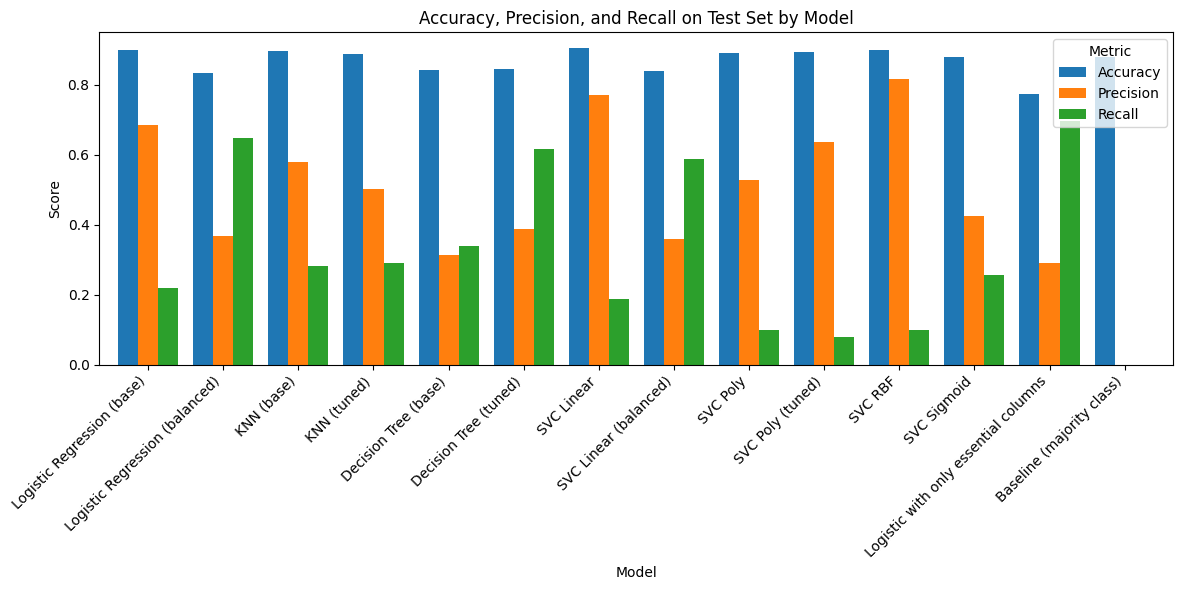

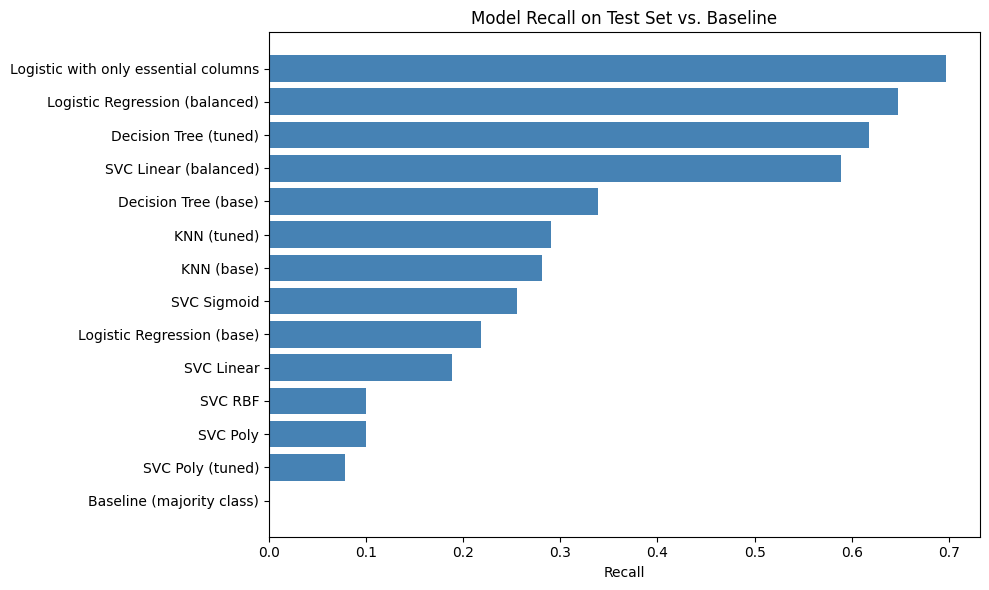

In [54]:
# Logistic/KNN/Decision Tree rows: full dataset, full feature set.
# SVC rows: smaller sample (bank-additional.csv) — not comparable to the full-dataset baseline above.
# "Essential cols" row: full dataset size, but only 6 features — not comparable on feature set either.
# Baseline row: always predicting the majority class ('no') — precision/recall are 0

# Add baseline as its own row so it appears in the table and both charts automatically
baseline_row = pd.DataFrame({
    'Model': ['Baseline (majority class)'],
    'Train Accuracy': [0.88],
    'Accuracy': [0.88],
    'Precision': [0.0],
    'Train Recall': [0.0],
    'Recall': [0.0],
})

# concat rather than .append() — append is deprecated in recent pandas versions
comparison_with_baseline = pd.concat([comparison, baseline_row], ignore_index=True)

# Display the table itself, sorted by recall, the priority metric
display(comparison_with_baseline.sort_values('Recall', ascending=False))

# --- Graph 1: Grouped bar chart comparing all 3 metrics across every model ---
comparison_with_baseline.set_index('Model')[['Accuracy', 'Precision', 'Recall']].plot(
    kind='bar',
    figsize=(12, 6),
    width=0.8
)
plt.title('Accuracy, Precision, and Recall on Test Set by Model')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

# --- Graph 2: Recall-focused horizontal bar chart ---
recall_sorted = comparison_with_baseline.sort_values('Recall', ascending=True)
plt.figure(figsize=(10, 6))

# Color the baseline bar differently so it's visually distinct from real models
bar_colors = ['red' if model == 'Baseline (majority class)' else 'steelblue'
              for model in recall_sorted['Model']]

plt.barh(recall_sorted['Model'], recall_sorted['Recall'], color=bar_colors)
plt.xlabel('Recall')
plt.title('Model Recall on Test Set vs. Baseline')
plt.tight_layout()
plt.show()


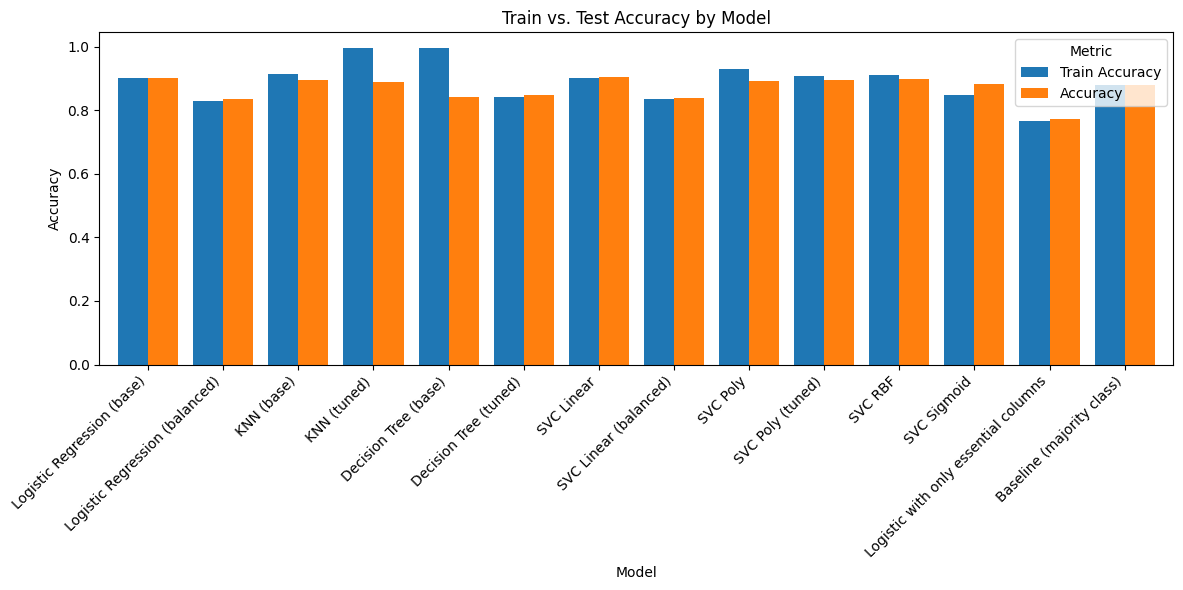

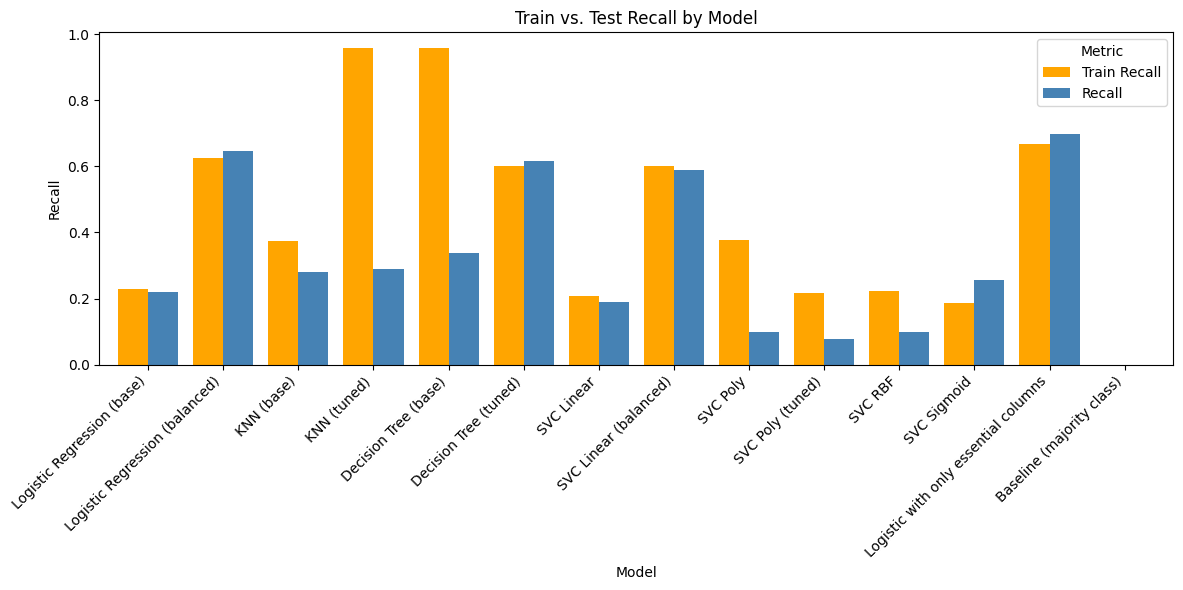

In [55]:
# Added: Train vs. Test comparison graphs, using the Train Accuracy/Train Recall
# columns added above, to check each model for overfitting (train much higher than test).

# --- Graph 3: Train vs. Test Accuracy, grouped by model ---
comparison_with_baseline.set_index('Model')[['Train Accuracy', 'Accuracy']].plot(
    kind='bar',
    figsize=(12, 6),
    width=0.8
)
plt.title('Train vs. Test Accuracy by Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

# --- Graph 4: Train vs. Test Recall, grouped by model ---
comparison_with_baseline.set_index('Model')[['Train Recall', 'Recall']].plot(
    kind='bar',
    figsize=(12, 6),
    width=0.8,
    color=['orange', 'steelblue']
)
plt.title('Train vs. Test Recall by Model')
plt.ylabel('Recall')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


##### Questions